Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
import shap

Load Data

In [3]:
train_df = pd.read_csv("data/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("data/UNSW_NB15_testing-set.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(82332, 45) (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Inspect Columns

In [ ]:
train_df.columns.tolist()

Prepare Binary Task

In [ ]:
target = "label"
drop_cols = [c for c in ["id", "attack_cat", target] if c in train_df.columns]

X_train = train_df.drop(columns=drop_cols).copy()
y_train = train_df[target].copy()

X_test = test_df.drop(columns=drop_cols).copy()
y_test = test_df[target].copy()

X_train.head()

Encode Categoricals

In [6]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

['proto', 'service', 'state']

In [7]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(X_train.shape, X_test.shape)

(82332, 187) (175341, 187)


# Decision Tree Lab

In [8]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=100,
    random_state=42
)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_preds))
print("Precision:", precision_score(y_test, dt_preds))
print("Recall:", recall_score(y_test, dt_preds))
print("F1:", f1_score(y_test, dt_preds))

Decision Tree
Accuracy: 0.8988029040555261
Precision: 0.962052373545811
Recall: 0.8862754627495999
F1: 0.9226105843459146


Plot the Tree

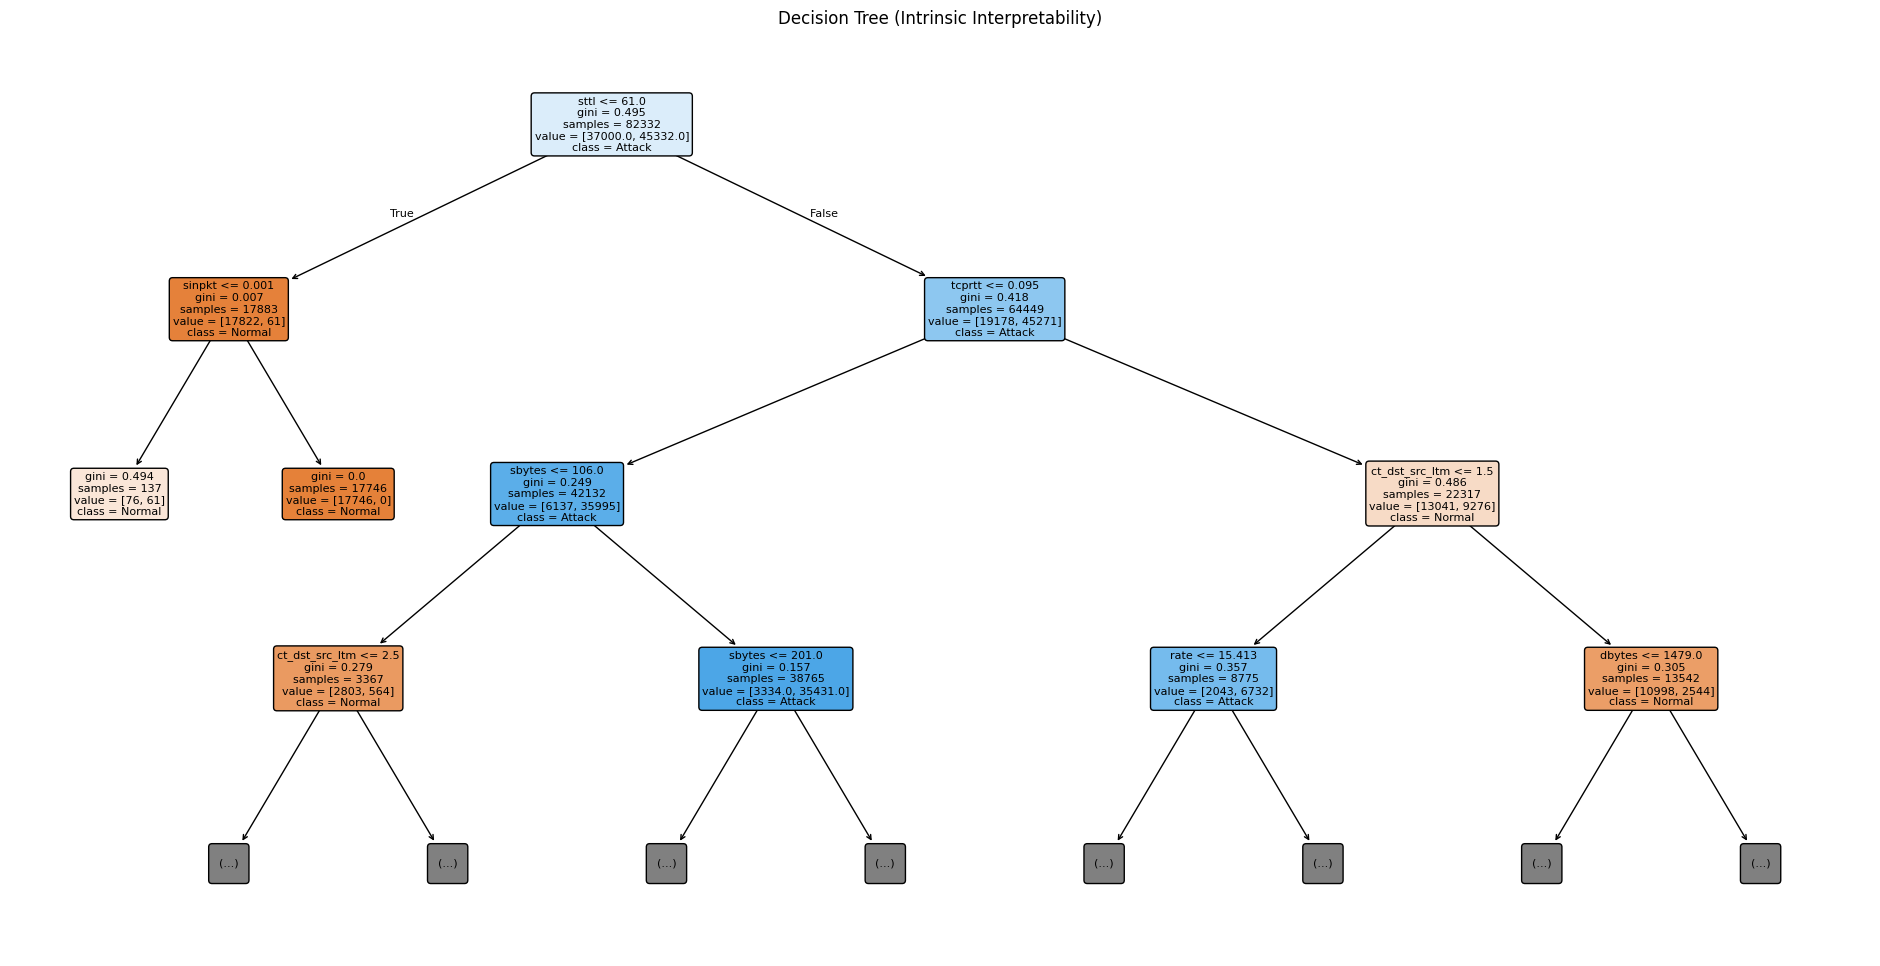

In [9]:
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Normal", "Attack"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree (Intrinsic Interpretability)")
plt.show()

Show Top Tree Importances

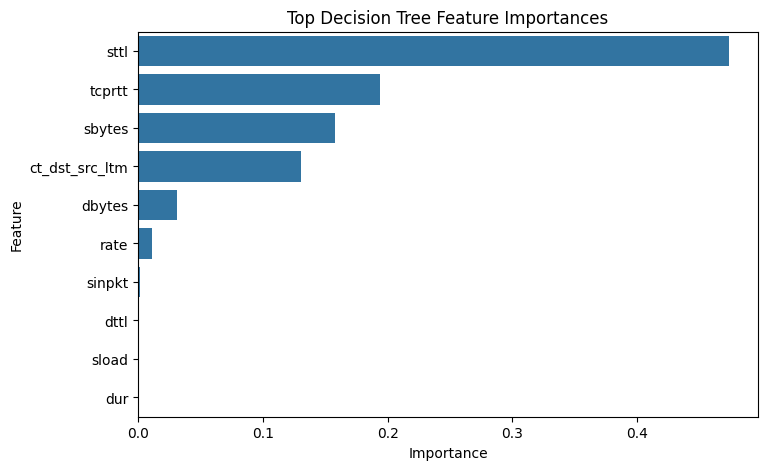

In [10]:
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
dt_top = dt_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=dt_top.values, y=dt_top.index)
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# XGBoost Lab

In [11]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1:", f1_score(y_test, xgb_preds))

XGBoost
Accuracy: 0.8996070514026954
Precision: 0.9883267735432466
Recall: 0.8626875926965586
F1: 0.9212432497729418


# SHAP Lab

Global Explanation

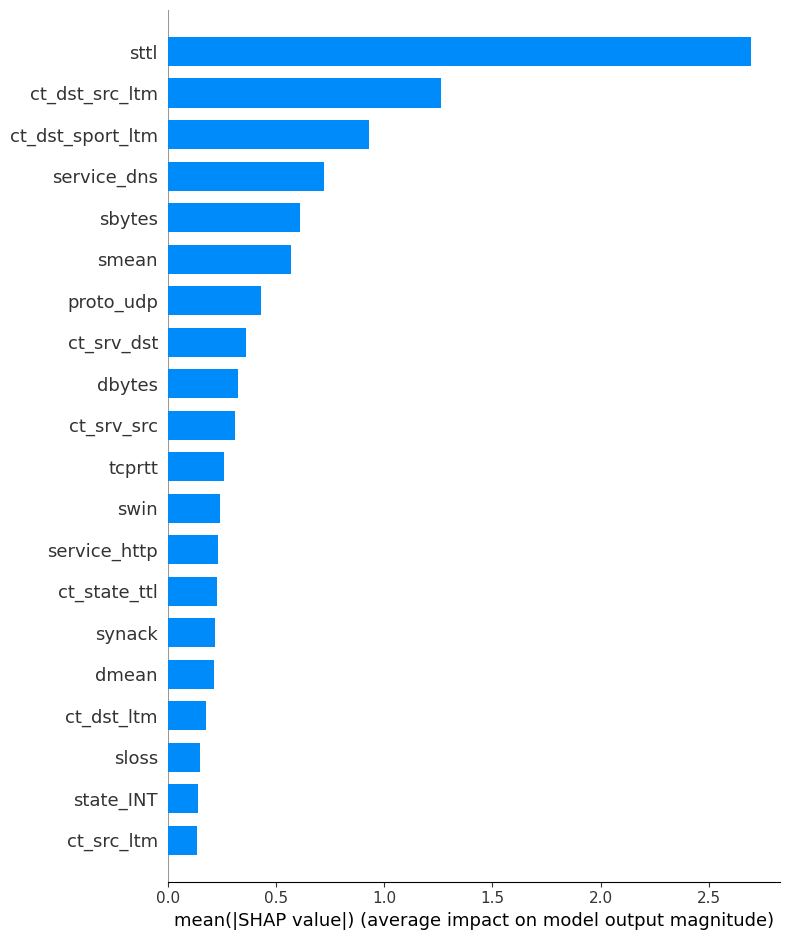

In [12]:
explainer = shap.TreeExplainer(xgb_model)
sample_X = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X, plot_type="bar")

Local Explanation

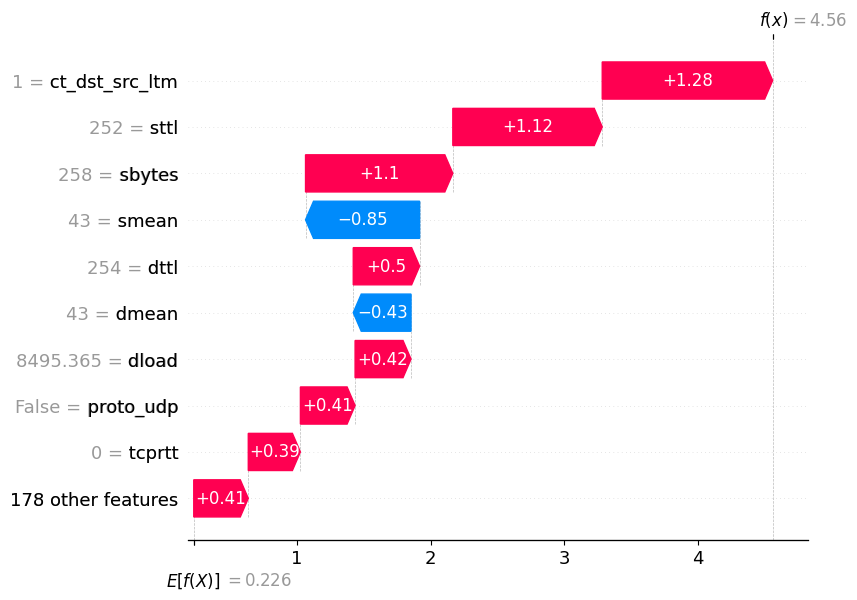

In [13]:
sample_idx = np.where(xgb_preds == 1)[0][0]
one_x = X_test.iloc[[sample_idx]]

one_shap = explainer.shap_values(one_x)
shap.plots.waterfall(
    shap.Explanation(
        values=one_shap[0],
        base_values=explainer.expected_value,
        data=one_x.iloc[0].values,
        feature_names=one_x.columns
    )
)